---
# Deep Learning (COSC 2779 / 2792)
# Assignment 2: Deep Learning — Sequence Modelling

## Sridhar Srinath *(Student ID: **S4182099**)*
---
**What I'm building.** Litmus wants a tool that looks at the text of a meme and:
* **Part A:** says which of the 20 persuasion techniques it uses;
* **Part B:** points *where* in the text each technique is;
* **Part C:** helps answer the curriculum committee's four questions (bias, whether a zer-shot model would do, whether the two output agree, and whether it'll work for Australian year 10 students in 2026).

**How I approached it.** The only things I fixed before training were the evaluation setup (§3) and one rule for deciding whether a change is worth keeping (§4). After that, every step in §5 comes from something I measured in the step before. The pattern is always: run something, look at what it printed, explain what that means, then decide what to try next. The test set isn't touched until §7, once the design is locked in.

| § | What happens there |
|---|---|
| 1–2 | Load the data, sanity-check it, and explore it to decide the output format, metric and risks |
| 3 | Metrics, trivial baselines, targets and the cross-validation split |
| 4 | The model and how it's trained |
| 5 | Development, one measured step at a time |
| 6 | Train the final model, save it, reload it, time it |
| 7–8 | Test once, then dig into the errors and check the explanations |
| 9 | Part C: C1 bias, C2 zero-shot comparison, C3 head agreement, C4 Australian context |
| 10 | Final judgment and recommendation |

---
## 0. Setup

In [1]:
!pip install -q "transformers==4.51.3" "peft==0.14.0" "huggingface_hub==0.30.2" accelerate

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import os, re, json, time, random, copy, zipfile, glob, warnings
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
from collections import Counter, defaultdict
import transformers
from datetime import datetime
from IPython.display import HTML, display
from peft import LoraConfig, get_peft_model
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device, torch.cuda.get_device_name(0) if torch.cuda.is_available() else '','- transformers', transformers.__version__)

cuda Tesla T4 - transformers 4.51.3


In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [5]:
SEED = 42
set_seed(SEED)

In [6]:
ENCODER_NAME = 'distilbert-base-uncased' # Starting encoder
MAX_LEN = 128 # MAX_LEN checked against token lengths
BATCH_SIZE = 16
N_FOLDS = 5 # 5-fold CV
STOP_FRAC = 0.10 # 10 % of each training fold used only for early stopping
MAX_EPOCHS = 15
PATIENCE = 3
PROBE_EPOCHS = 2
HEAD_LR = 1e-3 # Linear-probe learning rate for the new heads

**Constraints from brief, and how I'm meeting them**
* **Runs on the device:** only local models, no hosted APIs (this matters again in C2).
* **One T4:** latency is actually measured in §6, not assumed.
* **General-purpose encoders only:** DistilBERT and BERT-base, which were pretrained on Wikipedia and books and have never seen persuasion labels.
* **No extra data:** no outside corpora and no augmentation (reason in §2).
* **Neural networks only:** the keyword lists in C1/C4 are just for picking memes to analyse. They're never part of the tool.
* **A self-built part that gets trained:** the label head and span head in §4.

---
## 1. Data

The task-1 files have each meme's set of techniques (Part A) and the task-2 files have the character spans (Part B). I combine train and dev into one 751-meme development pool, because 751 memes is already small and splitting off a fixed dev set would waste data (more on that in §3). The test set stays unloaded until §7.

In [7]:
# Find the data folder (unzip the file if needed)
def find(pattern):
    hits = glob.glob(f'**/{pattern}', recursive=True) + glob.glob(f'../*/{pattern}') + glob.glob(f'../*/*/{pattern}')
    return [h for h in hits if '__MACOSX' not in h]

if not find('training_set_task1*'):
    for zip_path in find('*.zip'):
        with zipfile.ZipFile(zip_path) as z:
            if any('training_set_task1' in n for n in z.namelist()):
                z.extractall('data_2026_A2_extracted')

hits = find('training_set_task1*')
assert hits, f'training_set_task1.txt not found. Notebook folder: {os.getcwd()} contains {os.listdir(".")}'
DATA_DIR = os.path.dirname(hits[0])
print('Data folder:', DATA_DIR)

Data folder: data_2026_A2/data


In [8]:
ALL_22 = ['Appeal to authority', 'Appeal to fear/prejudice', 'Black-and-white Fallacy/Dictatorship', 'Causal Oversimplification',
          'Doubt', 'Exaggeration/Minimisation', 'Flag-waving', 'Glittering generalities (Virtue)', 'Loaded Language',
          "Misrepresentation of Someone's Position (Straw Man)", 'Name calling/Labeling', 'Obfuscation, Intentional vagueness, Confusion',
          'Presenting Irrelevant Data (Red Herring)', 'Reductio ad hitlerum', 'Repetition', 'Slogans', 'Smears',
          'Thought-terminating cliché', 'Whataboutism', 'Bandwagon', 'Transfer', 'Appeal to (Strong) Emotions']

if os.path.exists('techniques_list_task3.txt'):
    ALL_22 = [l.strip() for l in open('techniques_list_task3.txt', encoding='utf-8') if l.strip()]

# the last two are image-only techniques
TECHNIQUES = ALL_22[:20]
N_LABELS = len(TECHNIQUES)
T2I = {t: i for i, t in enumerate(TECHNIQUES)}

def load_split(name):
    t1 = json.load(open(os.path.join(DATA_DIR, f'{name}_set_task1.txt'), encoding='utf-8'))
    t2 = {d['id']: d for d in json.load(open(os.path.join(DATA_DIR, f'{name}_set_task2.txt'), encoding='utf-8'))}
    return [{'id': d['id'], 'text': d['text'], 'labels': set(d['labels']), 'spans': [(s['start'], s['end'], s['technique']) for s in t2[d['id']]['labels']]} for d in t1]

pool_docs = load_split('training') + load_split('dev')
labels_to_matrix = lambda sets: np.array([[1 if t in s else 0 for t in TECHNIQUES] for s in sets])
Y_pool = labels_to_matrix([d['labels'] for d in pool_docs])
print('Development pool:', len(pool_docs))
print('Techniques used:', len(set().union(*[d['labels'] for d in pool_docs])))
print('Outside the 20-label list:', set().union(*[d['labels'] for d in pool_docs]) - set(TECHNIQUES))
print('Label set: Union of span techniques:', sum(d['labels'] == {s[2] for s in d['spans']} for d in pool_docs), '/', len(pool_docs))

Development pool: 751
Techniques used: 20
Outside the 20-label list: set()
Label set: Union of span techniques: 751 / 751


**What this tells me**
* **751 / 751** memes have a label set that's exactly the union of their span techniques. So Part A and Part B aren't two separate annotations; the labels are just the spans summarised. That's a good reason to try **one model with two heads** instead of two models, and it's also why comparing the two heads in C3 makes sense.
* Exactly **20** techniques show up and none are outside the list, so the output layer gets 20 labels. The other two techniques in the full list of 22 are image-only, which doesn't apply to a text model.

---
## 2. Exploratory data analysis
The point of this section is to let the data decide a few design choices before any model exists.

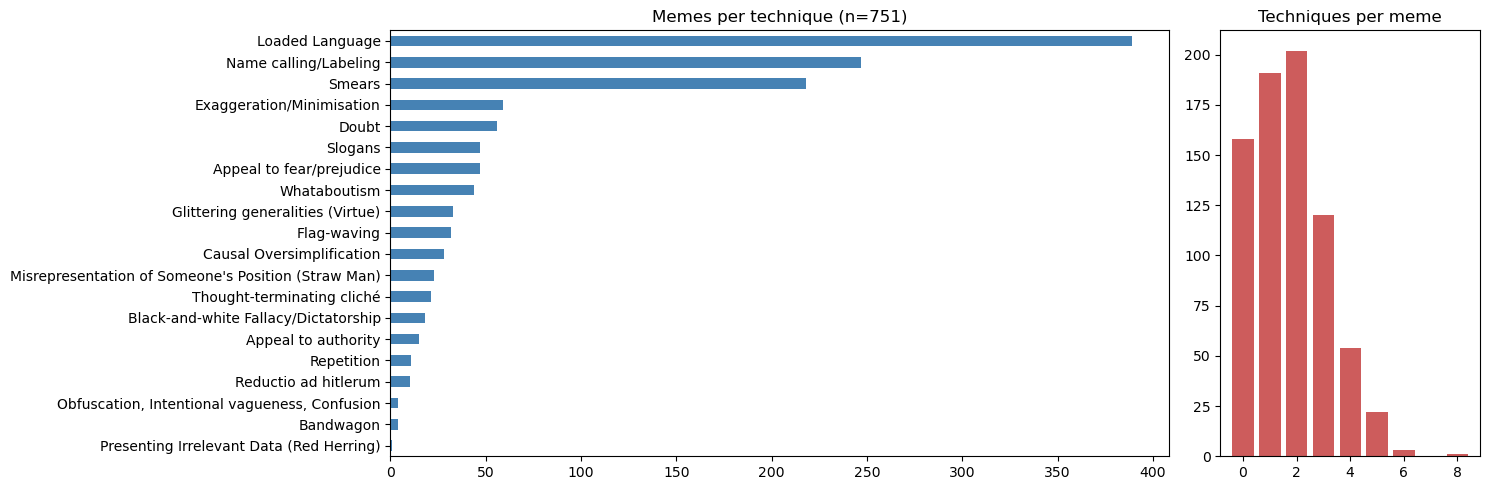

In [9]:
counts = pd.Series(Y_pool.sum(0), index=TECHNIQUES).sort_values(ascending=False)
n_per = Y_pool.sum(1)
fig, ax = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [3, 1]})
counts.plot.barh(ax=ax[0], color='steelblue')
ax[0].invert_yaxis()
ax[0].set_title('Memes per technique (n=751)')
ax[1].bar(*np.unique(n_per, return_counts=True), color='indianred')
ax[1].set_title('Techniques per meme')
plt.tight_layout()
plt.show()

In [10]:
print(f'Most / Least frequent: {counts.max()}/{counts.min()}')

Most / Least frequent: 389/1


In [11]:
print(f'Techniques with <10 memes: {list(counts[counts < 10].index)}')

Techniques with <10 memes: ['Obfuscation, Intentional vagueness, Confusion', 'Bandwagon', 'Presenting Irrelevant Data (Red Herring)']


In [12]:
print(f'Memes with no technique: {(n_per == 0).mean():.0%}')
print(f'Mean techniques per meme: {n_per.mean():.2f}')

Memes with no technique: 21%
Mean techniques per meme: 1.74


In [13]:
# Span length and overlap
span_words = defaultdict(list)
whole = Counter()
overlap = 0
tagged = 0
docs_overlap = 0
for d in pool_docs:
    cover = [set() for _ in d['text']]
    for s, e, t in d['spans']:
        span_words[t].append(len(d['text'][s:e].split()))
        whole[t] += (e - s) >= 0.8 * len(d['text'].rstrip())
        for i in range(s, min(e, len(d['text']))): cover[i].add(t)
    real = [c for i, c in enumerate(cover) if c and not d['text'][i].isspace()]
    tagged += len(real)
    ov = sum(len(c) > 1 for c in real)
    overlap += ov
    docs_overlap += ov > 0
span_df = pd.DataFrame({'median words': {t: np.median(v) for t, v in span_words.items()}, 'share covering >80% of meme': {t: whole[t] / len(v) for t, v in span_words.items()}}).loc[counts.index].round(2)
display(span_df.head(10).T)

,Loaded Language,Name calling/Labeling,Smears,Exaggeration/Minimisation,Doubt,Slogans,Appeal to fear/prejudice,Whataboutism,Glittering generalities (Virtue),Flag-waving
median words,1.0,2.00,15.00,5.00,11.50,3.00,8.5,23.0,10.50,4.00
share covering >80% of meme,0.0,0.02,0.64,0.12,0.41,0.12,0.1,0.7,0.38,0.03


In [14]:
print(f'Tagged characters with 2+ techniques: {overlap / tagged:.0%}')
print(f'Memes with overlap: {docs_overlap}/{len(pool_docs)}')

Tagged characters with 2+ techniques: 36%
Memes with overlap: 373/751


In [15]:
# Length, casing, topic
tok0 = AutoTokenizer.from_pretrained(ENCODER_NAME)
n_tok = np.array([len(tok0(d['text'])['input_ids']) for d in pool_docs])
caps = np.mean([sum(c.isupper() for c in d['text']) / max(1, sum(c.isalpha() for c in d['text'])) > 0.7 for d in pool_docs])
us = np.mean([bool(re.search(r'trump|biden|obama|clinton|democrat|republican|liberal|conservative|covid|america', d['text'].lower())) for d in pool_docs])
au = sum(bool(re.search(r'australia|aussie|albanese|dutton|\blabor\b', d['text'].lower())) for d in pool_docs)
print(f'Max tokens {n_tok.max()} (> MAX_LEN: {(n_tok > MAX_LEN).sum()})')
print(f'Mostly-capitals memes {caps:.0%}, US politics/COVID memes {us:.0%}, Australian memes {au}')

Max tokens 101 (> MAX_LEN: 0)
Mostly-capitals memes 48%, US politics/COVID memes 33%, Australian memes 1


**What the exploration tells me, and the design decision each finding leads to**

| What the output shows | What it means | So I... |
|---|---|---|
| *Loaded Language* is in 389 memes, *Red Herring* in 1, and three techniques have fewer than 10 | The classes are really imbalanced, so any metric that pools every decision will be dominated by the top two or three techniques | use a metric that weights each technique equally (§3), and keep an eye out for rare techniques being ignored |
| Memes have 0 to 8 techniques each, and **21 %** have none | It's multi-label, and "nothing" is a valid answer | use one sigmoid per technique with binary cross-entropy. Softmax would force exactly one answer per meme, which is wrong here |
| **36 %** of tagged characters belong to 2+ techniques, across **373** memes | The same words often count for several techniques at once | make the span head output 20 independent yes/no values per token. Normal BIO tagging only allows one tag per token, so it can't represent this |
| *Loaded Language* spans are 1 word (median), but *Smears* covers over 80 % of the meme in 64 % of cases | Some techniques are single words, others are basically the whole meme | add a "highlight the whole meme" baseline in §3, because a character-level metric will reward over-highlighting |
| The longest meme is **101** tokens, so nothing gets cut off; **48 %** are mostly in capitals | Texts are short and caps are everywhere | set `MAX_LEN = 128`, and use uncased encoders so "LIBERALS" and "liberals" look the same |
| **33 %** mention US politics or COVID, and only **1** meme is Australian | The model could learn US names as shortcuts, and the actual deployment setting isn't in the data | test this directly with name swaps (C1) and an Australian shift (C4) |

**Where the data comes from.** Dimitrov et al. (2021) collected English memes from public Facebook groups during 2020, mostly US/Canadian political ones. Several annotators labelled each meme and then agreed on a final version.

A few things follow from that:
* The labels are human judgements, so the tool should present them as something to discuss, not as facts.
* I didn't add any other corpora, since their labels could overlap with this test set.
* I didn't use augmentation either. Swapping synonyms can change the technique itself ("traitor" → "opponent" removes the *Loaded Language*), so it doesn't preserve the label.

---
## 3. Evaluation framework
**Metrics**
* **Part A (primary): macro-F1** over the techniques that are present. The tool is supposed to teach every technique, not just the common ones, and the baseline table below shows why that matters.
* **Part B (primary): character-level macro-F1.** Predicted vs gold characters per technique. Characters give partial credit when a highlight overlaps the right words but isn't exact, which is fairer than all-or-nothing span matching.
* **Secondary:** micro-F1 and per-technique precision/recall, so I can see what's driving the macro score.

In [16]:
def doc_scores(Y, P):
    Y, P = np.asarray(Y), np.asarray(P).astype(int)
    tp, fp, fn = (Y * P).sum(0), ((1 - Y) * P).sum(0), (Y * (1 - P)).sum(0)
    f1 = np.where(2 * tp + fp + fn > 0, 2 * tp / np.maximum(2 * tp + fp + fn, 1), 0.0)
    return {'macro_f1': f1[Y.sum(0) > 0].mean(), 'micro_f1': 2 * tp.sum() / max(2 * tp.sum() + fp.sum() + fn.sum(), 1),
            'f1': f1, 'precision': np.where(tp + fp > 0, tp / np.maximum(tp + fp, 1), 0.0),
            'recall': np.where(tp + fn > 0, tp / np.maximum(tp + fn, 1), 0.0), 'support': Y.sum(0)}

def char_sets(text, spans):
    out = defaultdict(set)
    for s, e, t in spans:
        out[t].update(i for i in range(s, min(e, len(text))) if not text[i].isspace())
    return out

def span_scores(docs, preds):
    tp, fp, fn = Counter(), Counter(), Counter()
    for d, p in zip(docs, preds):
        g, q = char_sets(d['text'], d['spans']), char_sets(d['text'], p)
        for t in TECHNIQUES:
            tp[t] += len(g[t] & q[t])
            fp[t] += len(q[t] - g[t])
            fn[t] += len(g[t] - q[t])
    f1 = {t: 2 * tp[t] / (2 * tp[t] + fp[t] + fn[t]) if 2 * tp[t] + fp[t] + fn[t] else 0.0 for t in TECHNIQUES}
    T, FP, FN = sum(tp.values()), sum(fp.values()), sum(fn.values())
    return {'macro_f1': np.mean([f1[t] for t in TECHNIQUES if tp[t] + fn[t] > 0]), 'micro_f1': 2 * T / max(2 * T + FP + FN, 1), 'f1': f1}

freq_order = list(counts.index)
rows = [(n, *[doc_scores(Y_pool, labels_to_matrix([set(l)] * len(pool_docs)))[k] for k in ('macro_f1', 'micro_f1')])
        for n, l in [('predict all 20', TECHNIQUES), ('always top-1', freq_order[:1]), ('always top-3', freq_order[:3])]]
for n, labs in [('whole meme, all 20', lambda d: TECHNIQUES), ('whole meme, gold labels (oracle)', lambda d: d['labels'])]:
    s = span_scores(pool_docs, [[(0, len(d['text']), t) for t in labs(d)] for d in pool_docs])
    rows.append((n + ' [Part B]', s['macro_f1'], s['micro_f1']))
display(pd.DataFrame(rows, columns=['trivial baseline (dev pool)', 'macro-F1', 'micro-F1']).round(3))

,trivial baseline (dev pool),macro-F1,micro-F1
0,predict all 20,0.139,0.160
1,always top-1,0.034,0.378
2,always top-3,0.081,0.480
3,"whole meme, all 20 [Part B]",0.078,0.084
4,"whole meme, gold labels (oracle) [Part B]",0.619,0.576


In [17]:
# 5-fold CV; inside each fold 10 % of the training part is an early-stopping slice
FOLDS = []
for k, (tr, te) in enumerate(KFold(N_FOLDS, shuffle=True, random_state=SEED).split(np.arange(len(pool_docs)))):
    stop = np.sort(np.random.default_rng(SEED + k).choice(tr, size=int(STOP_FRAC * len(tr)), replace=False))
    FOLDS.append({'fit': np.setdiff1d(tr, stop), 'stop': stop, 'test': te})
print('Fold sizes (fit/stop/held-out):', [(len(f['fit']), len(f['stop']), len(f['test'])) for f in FOLDS])

Fold sizes (fit/stop/held-out): [(540, 60, 151), (541, 60, 150), (541, 60, 150), (541, 60, 150), (541, 60, 150)]


In [18]:
print('Techniques per held-out fold:', [int((Y_pool[f['test']].sum(0) > 0).sum()) for f in FOLDS])

Techniques per held-out fold: [17, 20, 19, 17, 19]


**Why macro-F1 (straight from the baseline table)**
Always predicting the three most common techniques gets a **micro-F1 of 0.480** but a **macro-F1 of only 0.081**. Micro-F1 pools every decision, so a "model" that says the same three things for every meme looks decent. Macro-F1 averages over techniques, so the same model scores close to nothing, which is what it deserves. Since the tool is meant to teach all the techniques, macro-F1 is the metric I use to choose between models. Micro-F1 stays as a sanity check.

**Targets (set now, before training anything)**

| | Minimum (worth using at all) | Deployment (safe for unsupervised class use) |
|---|---|---|
| Part A macro-F1 | **≥ 0.28** | **≥ 0.50** |
| Part A micro-F1 | must beat "always top-3" (0.480 on the pool) | — |
| Part B char macro-F1 | **≥ 0.16**, and must beat painting the model's own labels over the whole meme | **≥ 0.40** |

* **Minimum = roughly double the best trivial score.** "Predict all 20" gets 0.139 for Part A and the best label-free span baseline gets 0.078 for Part B. If a model can't double guessing, it isn't really finding techniques.
* **Deployment = 0.50.** In a classroom with no one checking, a wrong label actively mis-teaches, and a wrong *Smears* on a meme about someone's family's politics is a fairness problem. Below about 0.5 the tool is wrong roughly as often as it's right.
* **The painting rule for Part B.** The oracle row (gold labels painted over the whole meme) scores **0.619**, which shows this metric rewards highlighting everything. So the span head has to beat painting its *own* predicted labels over the whole meme, otherwise it isn't actually locating anything.

**How the data is split, and why**
* The **200 test memes** (a later `batch_2` collection) stay locked away until §7.
* **Design decisions use 5-fold CV** on the 751 memes. The printout shows each held-out fold has around 150 memes covering **17 to 20** techniques. A single 63-meme dev set would have 0 to 3 examples of the rare techniques, so any score on it would mostly be noise.
* **Early stopping uses its own 10 % slice** (60 memes) inside each training fold. The fold being scored never chooses the epoch, which fixes the data re-use problem from Assignment 1.
* Every configuration uses exactly the same folds and slices, so when two results differ it's because of the change, not because of a different split.

---
## 4. Model: shared encoder + two self-built heads
**Why it looks like this** (every reason here comes from §1–§3, not from results)
* **A pretrained transformer encoder.** 751 memes is nowhere near enough to learn English from scratch, so the model has to borrow language knowledge. I start with the smallest general-purpose encoder from the labs, **DistilBERT** (66 M parameters, uncased). It's quick on a T4, and uncased suits the all-caps memes from §2.
* **One shared encoder, two heads.** §1 showed both tasks come from the same annotation, and one forward pass gives both outputs. I'm not assuming sharing is free though; that gets tested in §5.
* **Loss:** $\mathcal{L}=\text{BCE}_{\text{label}}+\lambda\,\text{BCE}_{\text{span}}$ with λ = 1 to start. BCE because it's multi-label (§2). The span loss is averaged over real tokens only, so padding doesn't dilute it.
* **The self-built part** is the two heads, which start from random weights. The code also supports a BiLSTM span head, class weights and so on, but none of them are switched on unless something measured in §5 calls for it.

The printout under the code is a quick check that spans turn into token labels correctly. You can see "bernie" and "bros" carrying both *Name calling* and *Smears*, which is exactly the overlap §2 said I'd need to handle.

In [19]:
TOKENIZERS, ENCODED = {}, {}
def get_tokenizer(name):
    if name not in TOKENIZERS: TOKENIZERS[name] = AutoTokenizer.from_pretrained(name)
    return TOKENIZERS[name]

def encode_doc(doc, tok):
    enc = tok(doc['text'], truncation=True, max_length=MAX_LEN, return_offsets_mapping=True)
    off = enc['offset_mapping']
    tok_labels = np.zeros((len(off), N_LABELS), dtype=np.float32)
    for s, e, t in doc['spans']:
        for j, (a, b) in enumerate(off):
            # token overlaps the span
            if a != b and a < e and b > s: tok_labels[j, T2I[t]] = 1.0
    return {'input_ids': enc['input_ids'], 'offsets': off, 'tok_labels': tok_labels,
            'tok_mask': np.array([0.0 if a == b else 1.0 for a, b in off], dtype=np.float32), # 0 for [CLS]/[SEP]
            'doc_labels': np.array([t in doc['labels'] for t in TECHNIQUES], dtype=np.float32)}

def encoded_pool(name):
    if name not in ENCODED: ENCODED[name] = [encode_doc(d, get_tokenizer(name)) for d in pool_docs]
    return ENCODED[name]

def make_collate(pad_id):
    def collate(batch):
        B, T = len(batch), max(len(b['input_ids']) for b in batch)
        out = {'input_ids': torch.full((B, T), pad_id, dtype=torch.long), 'attention_mask': torch.zeros((B, T), dtype=torch.long),
               'tok_labels': torch.zeros((B, T, N_LABELS)), 'tok_mask': torch.zeros((B, T)),
               'doc_labels': torch.tensor(np.stack([b['doc_labels'] for b in batch]))}
        for i, b in enumerate(batch):
            n = len(b['input_ids'])
            out['input_ids'][i, :n] = torch.tensor(b['input_ids'])
            out['attention_mask'][i, :n] = 1
            out['tok_labels'][i, :n] = torch.tensor(b['tok_labels'])
            out['tok_mask'][i, :n] = torch.tensor(b['tok_mask'])
        return out
    return collate

class LitmusModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        enc = AutoModel.from_pretrained(cfg['encoder'])
        H = enc.config.hidden_size
        if cfg['strategy'] == 'lora':      # Week 9: LoRA on attention Query/Value
            targets = ['q_lin', 'v_lin'] if enc.config.model_type == 'distilbert' else ['query', 'value']
            enc = get_peft_model(enc, LoraConfig(r=8, lora_alpha=16, lora_dropout=0.1, target_modules=targets))
        self.encoder = enc
        self.doc_head = nn.Sequential(nn.Dropout(cfg['dropout']), nn.Linear(H, cfg['head_hidden']), nn.ReLU(),
                                      nn.Dropout(cfg['dropout']), nn.Linear(cfg['head_hidden'], N_LABELS))
        self.span_lstm = nn.LSTM(H, cfg['head_hidden'] // 2, batch_first=True, bidirectional=True) if cfg['span_head'] == 'bilstm' else None
        self.span_head = nn.Sequential(nn.Dropout(cfg['dropout']), nn.Linear(cfg['head_hidden'] if self.span_lstm else H, N_LABELS))

    def forward(self, input_ids, attention_mask):
        h = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        m = attention_mask.unsqueeze(-1).float()
        # mean over non-padding tokens
        doc_logits = self.doc_head((h * m).sum(1) / m.sum(1).clamp(min=1))
        tok = self.span_lstm(h)[0] if self.span_lstm is not None else h
        return doc_logits, self.span_head(tok)

# sanity check: spans -> token labels (overlaps allowed)
ex = encoded_pool(ENCODER_NAME)[2]
for tk, lab in list(zip(get_tokenizer(ENCODER_NAME).convert_ids_to_tokens(ex['input_ids']), ex['tok_labels']))[1:8]:
    print(f'{tk:>10s} -> {[TECHNIQUES[k][:14] for k in np.where(lab)[0]]}')

        so -> ['Smears']
    bernie -> ['Name calling/L', 'Smears']
      bros -> ['Name calling/L', 'Smears']
     haven -> ['Smears']
         ' -> ['Smears']
         t -> ['Smears']
 committed -> ['Smears']


**How training works (`train_model`)**
* **Full fine-tuning** trains the heads first with the encoder frozen and only then unfreezes everything. Otherwise random heads send big, noisy gradients into the pretrained weights at the start.
* After each epoch I check the loss on the **stopping slice**, keep a copy of the best epoch, and **restore it** after 3 epochs with no improvement. I use loss rather than macro-F1 for this because 60 memes is too few for a stable F1.
* **AdamW**, weight decay 0.01, learning rate 2e-5 for the encoder and 1e-3 for the heads, gradient clipping at 1.

**The decision rule (fixed now).** A more complicated option only replaces the current one if:
1. it improves mean macro-F1 by **at least 0.01**, and
2. it **wins in at least 4 of the 5 folds**.

With about 150 memes per fold, smaller or less consistent gains could easily be luck. The second condition matters most, because a big average can come from one lucky fold.

**Reading the learning curves (`diagnose`)**, using the Week 6 decision table:
* best epoch right at the epoch limit → **under-fitting** (still improving when training stopped);
* stopping-slice loss going back up after the best epoch → **over-fitting**;
* otherwise → **converged**.

In [20]:
def pos_weights(items, mode):
    if mode == 'none': return None, None
    Y = np.stack([it['doc_labels'] for it in items])
    T = np.concatenate([it['tok_labels'][it['tok_mask'] > 0] for it in items])
    w = lambda A: torch.tensor(np.clip(np.sqrt((len(A) - A.sum(0)) / np.maximum(A.sum(0), 1)), 1, 10), dtype=torch.float32, device=device)
    # sqrt(neg/pos), clipped to [1, 10]
    return w(Y), w(T)

def joint_loss(model, b, pw_doc, pw_tok):
    b = {k: v.to(device) for k, v in b.items()}
    d, s = model(b['input_ids'], b['attention_mask'])
    tok = F.binary_cross_entropy_with_logits(s, b['tok_labels'], pos_weight=pw_tok, reduction='none').mean(-1)
    return (F.binary_cross_entropy_with_logits(d, b['doc_labels'], pos_weight=pw_doc)
            + model.cfg['span_weight'] * (tok * b['tok_mask']).sum() / b['tok_mask'].sum().clamp(min=1))

def run_epoch(model, loader, pw, opt=None):
    model.train() if opt else model.eval()
    total, n = 0.0, 0
    with torch.set_grad_enabled(opt is not None):
        for b in loader:
            loss = joint_loss(model, b, *pw)
            if opt:
                opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            total += loss.item() * len(b['input_ids'])
            n += len(b['input_ids'])
    return total / n

def make_optimizer(model):
    heads = [p for n, p in model.named_parameters() if not n.startswith('encoder.') and p.requires_grad]
    enc = [p for p in model.encoder.parameters() if p.requires_grad]
    return torch.optim.AdamW([{'params': heads, 'lr': model.cfg['head_lr']}] + ([{'params': enc, 'lr': model.cfg['lr']}] if enc else []), weight_decay=0.01)

def set_encoder_trainable(model, flag):
    for n, p in model.encoder.named_parameters():
        p.requires_grad = ('lora_' in n) if model.cfg['strategy'] == 'lora' else flag

def train_model(cfg, fit_items, stop_items, seed=SEED):
    set_seed(seed)
    model = LitmusModel(cfg).to(device)
    collate = make_collate(get_tokenizer(cfg['encoder']).pad_token_id)
    g = torch.Generator()
    g.manual_seed(seed)
    fit = DataLoader(fit_items, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate, generator=g)
    stop = DataLoader(stop_items, batch_size=64, shuffle=False, collate_fn=collate)
    pw = pos_weights(fit_items, cfg['pos_weight'])
    hist = {'train_loss': [], 'stop_loss': []}
    # stage 1: heads only
    if cfg['strategy'] == 'full':
        set_encoder_trainable(model, False)
        opt = make_optimizer(model)
        for _ in range(PROBE_EPOCHS):
            hist['train_loss'].append(run_epoch(model, fit, pw, opt))
            hist['stop_loss'].append(run_epoch(model, stop, pw))
    set_encoder_trainable(model, cfg['strategy'] == 'full')
    opt = make_optimizer(model)
    best, best_state, bad = float('inf'), None, 0
    for _ in range(MAX_EPOCHS):
        hist['train_loss'].append(run_epoch(model, fit, pw, opt))
        sl = run_epoch(model, stop, pw)
        hist['stop_loss'].append(sl)
        if sl < best - 1e-4:
            best, bad, hist['best_epoch'] = sl, 0, len(hist['stop_loss'])
            # checkpoint
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        elif (bad := bad + 1) >= PATIENCE:
            break
    # restore best epoch
    model.load_state_dict(best_state)
    return model, hist

def predict(model, items):
    model.eval()
    loader = DataLoader(items, batch_size=64, collate_fn=make_collate(get_tokenizer(model.cfg['encoder']).pad_token_id))
    docs, toks = [], []
    with torch.inference_mode():
        for b in loader:
            d, s = model(b['input_ids'].to(device), b['attention_mask'].to(device))
            docs.append(torch.sigmoid(d).cpu().numpy())
            s = torch.sigmoid(s).cpu().numpy()
            toks += [s[i, :int(b['attention_mask'][i].sum())] for i in range(len(s))]
    return np.concatenate(docs), toks

def spans_from_tokens(item, tp, thr):
    spans = []
    for k in range(N_LABELS):
        on, j = (tp[:, k] > thr) & (item['tok_mask'] > 0), 0
        while j < len(on):
            if on[j]:
                start = j
                while j + 1 < len(on) and on[j + 1]: j += 1
                spans.append((item['offsets'][start][0], item['offsets'][j][1], TECHNIQUES[k]))
            j += 1
    return spans

RESULTS = {}
def cross_validate(name, cfg):
    items = encoded_pool(cfg['encoder'])
    oof_doc = np.zeros((len(items), N_LABELS))
    oof_tok = [None] * len(items)
    r = {'cfg': dict(cfg), 'fold_macro': [], 'fold_micro': [], 'fold_span': [], 'hist': []}
    t0 = time.time()
    for f in FOLDS:
        model, h = train_model(cfg, [items[i] for i in f['fit']], [items[i] for i in f['stop']])
        te = [items[i] for i in f['test']]
        p, tp = predict(model, te)
        s = doc_scores(Y_pool[f['test']], p > 0.5)
        r['fold_macro'].append(s['macro_f1'])
        r['fold_micro'].append(s['micro_f1'])
        r['hist'].append(h)
        r['fold_span'].append(span_scores([pool_docs[i] for i in f['test']], [spans_from_tokens(it, x, 0.5) for it, x in zip(te, tp)])['macro_f1'])
        for j, i in enumerate(f['test']): oof_doc[i], oof_tok[i] = p[j], tp[j]
        r['trainable'] = sum(p.numel() for p in model.parameters() if p.requires_grad)
        del model
        torch.cuda.empty_cache()
    r.update(oof_doc=oof_doc, oof_tok=oof_tok, minutes=(time.time() - t0) / 60)
    RESULTS[name] = r
    print(f"{name:<28s} macro-F1 {np.mean(r['fold_macro']):.3f} ± {np.std(r['fold_macro']):.3f}, micro {np.mean(r['fold_micro']):.3f}, "
          f"span macro {np.mean(r['fold_span']):.3f}, best epochs {[h['best_epoch'] for h in r['hist']]}, "
          f"trainable {r['trainable'] / 1e6:.2f}M, {r['minutes']:.1f} min")
    return r

def better(base, new, metric='fold_macro'):
    d = np.array(RESULTS[new][metric]) - np.array(RESULTS[base][metric])
    wins = int((d > 0).sum())
    ok = d.mean() >= 0.01 and wins >= N_FOLDS - 1
    print(f'[{metric}] {new} vs {base}: gain {d.mean():+.3f}, wins {wins}/{N_FOLDS} -> {"ADOPT" if ok else "KEEP"} {new if ok else base}')
    return ok

def diagnose(name):
    H = RESULTS[name]['hist']
    limit = MAX_EPOCHS + (PROBE_EPOCHS if RESULTS[name]['cfg']['strategy'] == 'full' else 0)
    best = np.array([h['best_epoch'] for h in H])
    gap = np.mean([h['stop_loss'][h['best_epoch'] - 1] - h['train_loss'][h['best_epoch'] - 1] for h in H])
    if np.mean(best >= limit - 2) >= 0.6: v = 'UNDERFITTING (best epoch at the epoch limit)'
    elif np.mean([h['stop_loss'][-1] > min(h['stop_loss']) + 0.005 for h in H]) >= 0.6: v = 'OVERFITTING (slice loss rises after best epoch)'
    else: v = 'CONVERGED'
    print(f'{name}: best epochs {best.tolist()}, slice-train gap {gap:+.3f} -> {v}')
    return v

def plot_curves(names):
    fig, axes = plt.subplots(1, len(names), figsize=(5 * len(names), 3.3), squeeze=False)
    for ax, n in zip(axes[0], names):
        for h in RESULTS[n]['hist']:
            ax.plot(h['train_loss'], 'C0', alpha=.5)
            ax.plot(h['stop_loss'], 'C1--', alpha=.7)
        ax.set_title(n, fontsize=9)
        ax.set_xlabel('epoch (blue train, orange stop-slice)')
    plt.tight_layout()
    plt.show()

## 5. Development, one measured step at a time
Each step goes the same way: a code cell measures something, the text underneath reads the output and says what it means, and only then does the next cell test a change. Everything uses the same folds and the rule from §4.

### 5.1 Starting point: how should the encoder be adapted?
Nothing's been measured yet, so I start with the three options, cheapest first:
* **frozen encoder + heads:** only the heads learn;
* **LoRA r = 8:** with a learning rate of 3e-4, because our epochs are only about 34 steps compared to about 220, so it needs bigger steps to get anywhere;
* **full fine-tuning:** heads first, then everything.

frozen                       macro-F1 0.102 ± 0.025, micro 0.469, span macro 0.038, best epochs [11, 7, 14, 12, 8], trainable 0.22M, 1.2 min
LoRA r=8                     macro-F1 0.117 ± 0.050, micro 0.472, span macro 0.047, best epochs [5, 7, 4, 9, 6], trainable 0.36M, 1.6 min
full fine-tune               macro-F1 0.084 ± 0.006, micro 0.460, span macro 0.034, best epochs [3, 3, 4, 4, 4], trainable 66.58M, 1.5 min


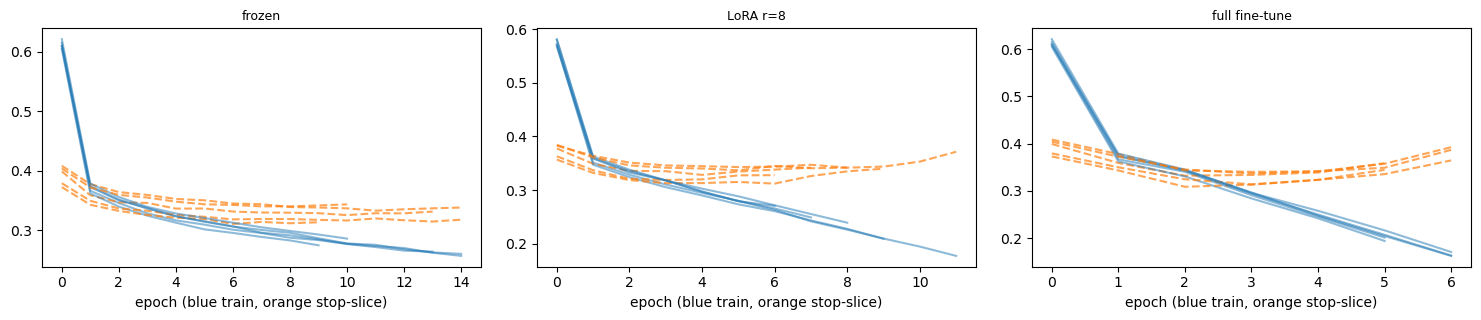

In [21]:
BASE = dict(encoder=ENCODER_NAME, strategy='frozen', lr=2e-5, head_lr=HEAD_LR, pos_weight='none', span_weight=1.0, span_head='linear', head_hidden=256, dropout=0.2)
cross_validate('frozen', BASE)
cross_validate('LoRA r=8', {**BASE, 'strategy': 'lora', 'lr': 3e-4})
cross_validate('full fine-tune', {**BASE, 'strategy': 'full'})
plot_curves(['frozen', 'LoRA r=8', 'full fine-tune'])

In [22]:
for n in ['frozen', 'LoRA r=8', 'full fine-tune']: diagnose(n)
BEST = 'frozen'
for cand in ['LoRA r=8', 'full fine-tune']:
    if better(BEST, cand): BEST = cand
print('Selected:', BEST)

frozen: best epochs [11, 7, 14, 12, 8], slice-train gap +0.042 -> CONVERGED
LoRA r=8: best epochs [5, 7, 4, 9, 6], slice-train gap +0.050 -> OVERFITTING (slice loss rises after best epoch)
full fine-tune: best epochs [3, 3, 4, 4, 4], slice-train gap +0.015 -> OVERFITTING (slice loss rises after best epoch)
[fold_macro] LoRA r=8 vs frozen: gain +0.015, wins 3/5 -> KEEP frozen
[fold_macro] full fine-tune vs frozen: gain -0.018, wins 1/5 -> KEEP frozen
Selected: frozen


**What came out**

| Strategy | Macro-F1 (5 folds) | Best epochs | What the curves look like |
|---|---|---|---|
| frozen | **0.102 ± 0.025** | 7–14 | train and slice loss go down together → *converged* |
| LoRA r = 8 | 0.117 ± 0.050 | 4–9 | slice loss flattens and then climbs while train loss keeps falling → *over-fitting* |
| full fine-tune | 0.084 ± 0.006 | 3–4 | train loss drops to about 0.17 while slice loss rises after epoch 3–4 → *over-fitting* |

**How I decided**
* LoRA does have a higher average (+0.015), but it only beat frozen in **3 of 5** folds, and its spread (± 0.050) is twice frozen's. One or two good folds are carrying that average, so by the rule it's noise, not an improvement.
* Full fine-tuning is worse on average and only won 1 fold.
* The curves explain why. Once the encoder is allowed to change, the model has millions of parameters to fit about 540 memes, so it starts memorising them: train loss keeps dropping while the held-out loss goes up. With the encoder frozen there are only 0.22 M trainable parameters, and the curves settle instead of diverging.

**Decision: keep the encoder frozen.** That said, 0.10 is nowhere near the 0.28 minimum, so the next question is where exactly it's failing.

### 5.2 Where does the frozen model fail?
Breaking the out-of-fold F1 down per technique, sorted from most to least common.

In [23]:
f1_before = doc_scores(Y_pool, RESULTS[BEST]['oof_doc'] > 0.5)['f1']
zero = [t for t, f in zip(TECHNIQUES, f1_before) if f == 0]
print(f'{len(zero)} of 20 techniques have out-of-fold F1 = 0:')
display(pd.DataFrame({'memes in pool': Y_pool.sum(0).astype(int), 'OOF F1': f1_before.round(3)}, index=TECHNIQUES).sort_values('memes in pool', ascending=False).T)

15 of 20 techniques have out-of-fold F1 = 0:


,Loaded Language,Name calling/Labeling,Smears,Exaggeration/Minimisation,Doubt,Slogans,Appeal to fear/prejudice,Whataboutism,Glittering generalities (Virtue),Flag-waving,Causal Oversimplification,Misrepresentation of Someone's Position (Straw Man),Thought-terminating cliché,Black-and-white Fallacy/Dictatorship,Appeal to authority,Repetition,Reductio ad hitlerum,"Obfuscation, Intentional vagueness, Confusion",Bandwagon,Presenting Irrelevant Data (Red Herring)
memes in pool,389.000,247.000,218.000,59.0,56.0,47.000,47.0,44.0,33.0,32.000,28.0,23.0,21.0,18.0,15.0,11.0,10.0,4.0,4.0,1.0
OOF F1,0.741,0.484,0.461,0.0,0.0,0.042,0.0,0.0,0.0,0.061,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**What came out:** **15 of the 20 techniques have an F1 of 0.** Only the most common ones get anything: *Loaded Language* 0.74, *Name calling* 0.48, *Smears* 0.46, plus tiny scores for *Slogans* and *Flag-waving*. Everything from *Exaggeration* (59 memes) downwards is zero.

**What that means**
* With a plain BCE loss, a rare technique is "no" in nearly every meme. So predicting "no" every time is almost free in terms of loss, and the model just learns to do that. That's exactly the pattern here: the cut-off between "learned" and "ignored" follows frequency, not how hard the technique is.
* So the problem isn't the encoder. It's that **the loss is dominated by the common techniques**, which is the imbalance I spotted in §2.

**What I'll try, and why this version of it**
* Give the positive examples of rare techniques more weight using `pos_weight = sqrt(neg/pos)`.
* I take the **square root** and **clip it at 10** on purpose. The raw ratio for a technique with 2 examples would be around 375, which would let two memes dominate every batch and wreck training.
* Something to watch for later: weighting pushes the model towards saying "yes" more, so false alarms will probably go up.

The trigger in the code (5 or more techniques at zero) is written down before running it, so the test only happens because of this output.

In [26]:
# trigger from the output above
if len(zero) >= 5:
    cross_validate('+ pos_weight', {**RESULTS[BEST]['cfg'], 'pos_weight': 'sqrt'})
    if better(BEST, '+ pos_weight'): BEST = '+ pos_weight'
    print('techniques at F1 = 0 after weighting:', int((doc_scores(Y_pool, RESULTS['+ pos_weight']['oof_doc'] > 0.5)['f1'] == 0).sum()))

+ pos_weight                 macro-F1 0.149 ± 0.034, micro 0.481, span macro 0.110, best epochs [5, 7, 9, 12, 6], trainable 0.22M, 1.0 min
[fold_macro] + pos_weight vs + pos_weight: gain +0.000, wins 0/5 -> KEEP + pos_weight
techniques at F1 = 0 after weighting: 9


**What came out**
* Macro-F1 goes from 0.102 to **0.149** (+0.047) and wins **all 5 folds**, so the rule says **ADOPT**.
* The number of techniques stuck at zero drops from 15 to **9**.
* The span score goes up too, from 0.038 to **0.110**, because the token-level loss is weighted the same way.

**Why I'm confident it's real:** it's a big gain, it shows up in every fold, and the drop in zero-F1 techniques shows it's fixing the exact problem I identified, not improving by accident.

**Decision: adopt class weighting.** Now that both heads are actually doing something, it's worth checking whether training them together is helping or hurting.

### 5.3 Does sharing the encoder cost Part A anything?
I went with one joint model in §4 because the two tasks share an annotation. But if the span loss were dragging the label head down, two separate models would be the better call. So I train the same model with the span loss turned off (λ = 0) and compare Part A.

In [27]:
cross_validate('Part A only (λ=0)', {**RESULTS[BEST]['cfg'], 'span_weight': 0.0})
print('Part A only is clearly better:', better(BEST, 'Part A only (λ=0)'))

Part A only (λ=0)            macro-F1 0.148 ± 0.037, micro 0.481, span macro 0.072, best epochs [5, 7, 9, 12, 6], trainable 0.22M, 1.0 min
[fold_macro] Part A only (λ=0) vs + pos_weight: gain -0.001, wins 3/5 -> KEEP + pos_weight
Part A only is clearly better: False


**What came out**
* **Part A:** without the span task it scores **0.148**, and the joint model scores **0.149**. That's a difference of 0.001 with 3/5 fold wins, so nothing in either direction.
* **Part B:** the Part-A-only model's span score drops to 0.072 (its span head was never trained), compared to 0.110 for the joint model.

**How I decided**
* Sharing costs Part A nothing measurable. That makes sense with a frozen encoder: the span loss can only update the span head, so it has no way of disturbing the features the label head uses. Even the best epochs are identical in both runs.
* Meanwhile, one joint model gives both outputs in a single forward pass, which is roughly half the latency of running two models.

**Decision: keep one joint model.** Next, which of the two heads is the weak one?

### 5.4 Which head is weaker?

In [28]:
cur = RESULTS[BEST]
print(f"label head macro-F1 {np.mean(cur['fold_macro']):.3f}, span head char macro-F1 {np.mean(cur['fold_span']):.3f}")

label head macro-F1 0.149, span head char macro-F1 0.110


**What came out:** the span head (**0.110**) is clearly behind the label head (**0.149**), so Part B is the weaker part.

**Why that might be, and what to try**
* The span head is a single linear layer that decides about every token **on its own**, without looking at the tokens around it.
* §2 showed lots of techniques cover whole clauses (*Smears* covers most of the meme in 64 % of cases). A token-by-token decision with no context can easily switch on and off in the middle of a clause, which breaks up the highlight.
* A **BiLSTM** reads the token sequence in both directions, so each token's decision can take the words on either side into account. I'll test it on the span metric with the same rule.

In [29]:
if np.mean(cur['fold_span']) < np.mean(cur['fold_macro']):    # trigger from the output above
    cross_validate('+ BiLSTM span head', {**cur['cfg'], 'span_head': 'bilstm'})
    if better(BEST, '+ BiLSTM span head', metric='fold_span'): BEST = '+ BiLSTM span head'

+ BiLSTM span head           macro-F1 0.155 ± 0.033, micro 0.480, span macro 0.121, best epochs [5, 7, 7, 11, 6], trainable 1.13M, 1.1 min
[fold_span] + BiLSTM span head vs + pos_weight: gain +0.011, wins 3/5 -> KEEP + pos_weight


**What came out**
* Span macro-F1 goes up by **+0.011** (0.110 → 0.121), but only wins **3 of 5** folds, so the rule says **KEEP** the linear head.
* The trainable head gets five times bigger, from 0.22 M to 1.13 M parameters.

**How I decided:** the average just clears the 0.01 bar, but two folds actually got worse, so I can't tell it apart from noise. Paying five times the parameters for something that doesn't hold up across folds isn't worth it.

**Decision: keep the linear span head.** The architecture's settled now, so the next thing to check is whether the model is being *trained* properly. That's what the learning curves are for.